# Data Preprocessing
Performer: Tùng Nguyễn (AE - Data)

# Coding Space

In [449]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import re
import os

In [450]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from pathlib import Path

## Anti-Leakage Data Processing Strategy

To prevent data leakage, the dataset is physically split into training and testing sets before any preprocessing steps are performed.

All data transformations, including missing value imputation, scaling, encoding, feature selection, and feature engineering, are fitted exclusively on the training set. The learned parameters are then applied to the testing set without re-fitting.

Pipeline order:

1. Load Raw Dataset
2. Data Understanding & Split
3. Fit Preprocessing on Train Dataset
4. Transform Train and Test using Train-fitted parameters

This approach ensures that no information from the testing set influences the training process, resulting in a more reliable estimate of model generalization performance.

### 1. Load raw dataset

In [451]:
# Load raw dataset
data_path = Path("../data/raw/data.csv")


df = pd.read_csv(data_path)
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [452]:
overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "n_unique": df.nunique(dropna=True).values,
    "sample_unique": [
        df[col]
        .dropna()
        .unique()[:5]
        .tolist()
        for col in df.columns
    ]
})

overview.sort_values("missing_pct", ascending=False)

,column,dtype,missing_count,missing_pct,n_unique,sample_unique
20,Plot Area,float64,187531,100.00,0,[]
19,Dimensions,float64,187531,100.00,0,[]
13,Society,str,109678,58.49,10376,"[Srushti Siddhi Mangal Murti Complex, Dosti Vi..."
18,Super Area,str,107685,57.42,2976,"[680 sqft, 575 sqft, 600 sqft, 1165 sqft, 844 ..."
16,Car Parking,str,103357,55.11,229,"[1 Open, 1 Covered, 2 Covered, 66 Covered, 701..."
12,overlooking,str,81436,43.43,19,"[Garden/Park, Garden/Park, Main Road, Main Roa..."
6,Carpet Area,str,80673,43.02,2758,"[500 sqft, 473 sqft, 779 sqft, 530 sqft, 635 s..."
11,facing,str,70233,37.45,8,"[East, West, North - East, North, North - West]"
17,Ownership,str,65517,34.94,4,"[Freehold, Co-operative Society, Power Of Atto..."
15,Balcony,str,48935,26.09,11,"[2, 1, 3, 4, > 10]"


**NOTE**

- Drop `index`, `title`, `description`, `status`, `society`: low predictive value for property price.
- Drop `dimensions`, `plot_area`: completely missing columns.
- Convert `car_parking` to categorical values (`open`, `covered`).
- Convert `amount` to numeric:
  - `1 Lac = 100,000`
  - `1 Cr = 10,000,000`
- Merge `carpet_area` and `super_area` into:
  - `area_sqft` (numeric)
  - `area_type` (`carpet`, `super`)
- Split `floor` into:
  - `room_floor` (current floor)
  - `total_floor` (building floors)

In [453]:
# Standardize column names
df.columns = (
    df.columns
    .str.replace(r"\(in rupees\)", "", regex=True)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)


# Remove unused columns
df = df.drop(
    columns=[
        "index",
        "title",
        "status",
        "description",
        "society",
        "dimensions",
        "plot_area",
    ]
)

In [454]:
# Convert car_parking to categorical
def normalize_parking(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if "covered" in value:
        return "covered"

    return "open"


df["car_parking"] = df["car_parking"].apply(normalize_parking)

In [455]:
# Convert bathroom, balcony
for col in ["bathroom", "balcony"]:
    df[col] = (
        df[col]
        .replace("> 10", "11")
        .pipe(pd.to_numeric, errors="coerce")
        .astype("Int64")
    )

In [456]:
# Convert amount to rupees
def convert_amount(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if "Cr" in value:
        number = float(value.replace("Cr", "").strip())
        return number * 1e7

    if "Lac" in value:
        number = float(value.replace("Lac", "").strip())
        return number * 1e5

    return np.nan


df["amount"] = df["amount"].apply(convert_amount)

In [457]:
# Convert area to numeric data and categorical data
def process_area_features(df):
    overlap_mask = (
        df["carpet_area"].notna()
        & df["super_area"].notna()
    )

    overlap_count = overlap_mask.sum()

    if overlap_count > 0:
        raise ValueError(
            f"Found {overlap_count} rows containing both "
            f"carpet_area and super_area"
        )

    df["area_type"] = np.where(
        df["carpet_area"].notna(),
        "carpet",
        "super"
    )

    df["area_sqft"] = (
        df["carpet_area"]
        .fillna(df["super_area"])
        .astype(str)
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

    df = df.drop(
        columns=[
            "carpet_area",
            "super_area"
        ]
    )

    return df


df = process_area_features(df)

In [458]:
# Convert floor
def process_floor_features(df):
    floor_parts = df["floor"].str.extract(
        r"(\d+)\s*out of\s*(\d+)"
    )

    df["room_floor"] = pd.to_numeric(
        floor_parts[0],
        errors="coerce"
    )

    df["total_floor"] = pd.to_numeric(
        floor_parts[1],
        errors="coerce"
    )

    df = df.drop(columns=["floor"])

    return df


df = process_floor_features(df)

In [459]:
df.head()

,amount,price,location,transaction,furnishing,facing,overlooking,bathroom,balcony,car_parking,ownership,area_type,area_sqft,room_floor,total_floor
0,4200000.0,6000.0,thane,Resale,Unfurnished,NaN,NaN,1,2,NaN,NaN,carpet,500.0,10.0,11.0
1,9800000.0,13799.0,thane,Resale,Semi-Furnished,East,Garden/Park,2,<NA>,open,Freehold,carpet,473.0,3.0,22.0
2,14000000.0,17500.0,thane,Resale,Unfurnished,East,Garden/Park,2,<NA>,covered,Freehold,carpet,779.0,10.0,29.0
3,2500000.0,NaN,thane,Resale,Unfurnished,NaN,NaN,1,1,NaN,NaN,carpet,530.0,1.0,3.0
4,16000000.0,18824.0,thane,Resale,Unfurnished,West,"Garden/Park, Main Road",2,<NA>,covered,Co-operative Society,carpet,635.0,20.0,42.0


In [460]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   amount       177847 non-null  float64
 1   price        169866 non-null  float64
 2   location     187531 non-null  str    
 3   transaction  187448 non-null  str    
 4   furnishing   184634 non-null  str    
 5   facing       117298 non-null  str    
 6   overlooking  106095 non-null  str    
 7   bathroom     186703 non-null  Int64  
 8   balcony      138596 non-null  Int64  
 9   car_parking  84174 non-null   str    
 10  ownership    122014 non-null  str    
 11  area_type    187531 non-null  str    
 12  area_sqft    186704 non-null  float64
 13  room_floor   167694 non-null  float64
 14  total_floor  167694 non-null  float64
dtypes: Int64(2), float64(5), str(8)
memory usage: 21.8 MB


### 2. Data Understanding & Split

#### 2.1. Target Analysis

In [461]:
target = "price"

df[target].describe()

count    1.698660e+05
mean     7.583772e+03
std      2.724171e+04
min      0.000000e+00
25%      4.297000e+03
50%      6.034000e+03
75%      9.450000e+03
max      6.700000e+06
Name: price, dtype: float64

In [462]:
print(
    f"Missing: {df[target].isna().sum():,}"
)

print(
    f"Missing %: {100 * df[target].isna().mean():.2f}%"
)

Missing: 17,665
Missing %: 9.42%


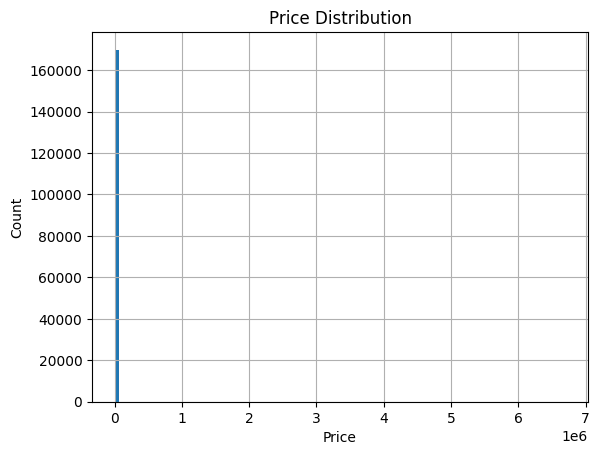

In [463]:
import matplotlib.pyplot as plt

df[target].hist(bins=100)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

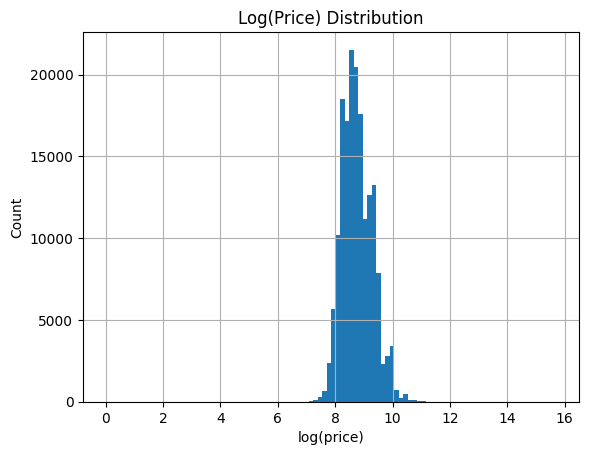

In [464]:
import numpy as np

np.log1p(df[target]).hist(
    bins=100
)

plt.title("Log(Price) Distribution")
plt.xlabel("log(price)")
plt.ylabel("Count")
plt.show()

In [465]:
df[target].skew()

np.float64(177.11336980623076)

In [466]:
df.nlargest(
    10,
    target
)[[target]]

,price
181234,6700000.0
147912,4500000.0
180679,4500000.0
176536,4041600.0
174894,3450000.0
175013,2669100.0
180481,1200000.0
174925,322727.0
183490,291667.0
172107,282609.0


**NOTE**

* `price` is heavily right-skewed.
* A small number of extremely expensive properties create a long upper tail.
* The maximum value is substantially larger than the median, indicating potential outliers.
* Log transformation (`log1p(price)`) produces a more balanced distribution.

**Recommendation**

* Keep all observations for now.
* Create an alternative target using: ```y = np.log1p(price)```

* Compare model performance between:

  * Raw `price`
  * Log-transformed `price`

* Review extreme price values later during train-only preprocessing.


#### 2.1.2. Missing Analysis

In [467]:
print(
    f"Missing target: "
    f"{df['price'].isna().sum():,}"
)

Missing target: 17,665


In [468]:
# Missingness Ranking
def missingness_ranking(df, target="price"):
    rows = []

    for col in df.columns:
        if col == target:
            continue

        missing_pct = (
            df[col].isna().mean() * 100
        )

        median_missing = df.loc[
            df[col].isna(),
            target
        ].median()

        median_present = df.loc[
            df[col].notna(),
            target
        ].median()

        impact_ratio = (
            median_present / median_missing
            if pd.notna(median_missing)
            and median_missing != 0
            else np.nan
        )

        if pd.isna(impact_ratio):
            impact = "N/A"
        else:
            symmetric_ratio = max(
                impact_ratio,
                1 / impact_ratio
            )

            if symmetric_ratio >= 1.25:
                impact = "Strong"
            elif symmetric_ratio >= 1.10:
                impact = "Moderate"
            else:
                impact = "Weak"

        rows.append({
            "feature": col,
            "dtype": str(df[col].dtype),
            "missing_pct": round(missing_pct, 2),
            "median_present": median_present,
            "median_missing": median_missing,
            "impact_ratio": round(impact_ratio, 2)
            if pd.notna(impact_ratio)
            else np.nan,
            "impact": impact
        })

    ranking = pd.DataFrame(rows)

    ranking = (
        pd.DataFrame(rows)
        .sort_values(
            by=["missing_pct", "impact_ratio"],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )

    return ranking


ranking = missingness_ranking(df)

ranking

,feature,dtype,missing_pct,median_present,median_missing,impact_ratio,impact
0,car_parking,str,55.11,7222.0,5455.0,1.32,Strong
1,overlooking,str,43.43,6650.0,5455.0,1.22,Moderate
2,facing,str,37.45,6650.0,5455.0,1.22,Moderate
3,ownership,str,34.94,6650.0,5333.0,1.25,Moderate
4,balcony,Int64,26.09,6182.0,5574.0,1.11,Moderate
5,room_floor,float64,10.58,6000.0,6607.0,0.91,Moderate
6,total_floor,float64,10.58,6000.0,6607.0,0.91,Moderate
7,amount,float64,5.16,6034.0,NaN,NaN,N/A
8,furnishing,str,1.54,6047.0,5389.0,1.12,Moderate
9,bathroom,Int64,0.44,6038.0,5389.0,1.12,Moderate


**Observation**

- Missing values are concentrated in a small number of features.
- `society` (58.49%) and `car_parking` (55.11%) exhibit the highest missing rates.
- Missingness in `society`, `car_parking`, `overlooking`, `facing`, and `ownership` is associated with noticeable differences in median property prices, suggesting informative missingness.
- Numeric features (`balcony`, `room_floor`, `total_floor`) show moderate missingness but relatively weak impact on the target.
- `price` contains 17,665 missing values (9.42%) and cannot be used directly for model training.
- Most remaining features have low missing rates (<2%).

**Recommendation**

- Remove rows with missing `price` before model training.
- Treat missing values in:
  - `society`
  - `car_parking`
  - `overlooking`
  - `facing`
  - `ownership`

  as a dedicated category (`Unknown`).

- Consider median imputation for:
  - `balcony`
  - `room_floor`
  - `total_floor`
  - `bathroom`
  - `area_sqft`

- Reassess `amount`, `area_sqft`, and `area_type` after investigating whether their missing values originate from upstream data quality issues.

- Final imputation rules should be fit on the training set only to prevent data leakage.

#### 2.1.3. Numeric Feature Analysis

In [469]:
numeric_cols = [
    "price",
    "amount",
    "area_sqft",
    "bathroom",
    "balcony",
    "room_floor",
    "total_floor"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,169866.0,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
amount,177847.0,11981344.189106,39438269.43287,100000.0,4840000.0,7800000.0,14500000.0,14003000000.0
area_sqft,186704.0,1245.597047,2348.544838,1.0,800.0,1140.0,1551.0,709222.0
bathroom,186703.0,2.428247,0.871107,1.0,2.0,2.0,3.0,11.0
balcony,138596.0,2.001782,0.958087,1.0,1.0,2.0,3.0,11.0
room_floor,167694.0,4.782049,4.665324,1.0,2.0,3.0,6.0,200.0
total_floor,167694.0,9.049328,7.768335,1.0,4.0,6.0,12.0,200.0


In [470]:
df[numeric_cols].corr()["price"] \
    .sort_values(ascending=False)

price          1.000000
amount         0.762790
bathroom       0.061210
balcony        0.039334
total_floor    0.038516
room_floor     0.033117
area_sqft      0.010871
Name: price, dtype: float64

In [471]:
# Create log-transformed features
df["log_price"] = np.log1p(df["price"])
df["log_amount"] = np.log1p(df["amount"])
df["log_area"] = np.log1p(df["area_sqft"])

In [472]:
log_cols = [
    "log_price",
    "log_amount",
    "log_area"
]

df[log_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
log_price,169866.0,8.761034,0.536597,0.000000,8.365905,8.705331,9.153876,15.717618
log_amount,177847.0,15.923140,0.821877,11.512935,15.392425,15.869634,16.489659,23.362537
log_area,186704.0,6.897282,0.817015,0.693147,6.685861,7.039660,7.347300,13.471925


In [473]:
numeric_feature_cols = [
    "log_amount",
    "log_area",
    "bathroom",
    "balcony",
    "room_floor",
    "total_floor"
]

df[
    ["log_price"] + numeric_feature_cols
].corr()["log_price"] \
 .sort_values(ascending=False)

log_price      1.000000
log_amount     0.795000
bathroom       0.343343
total_floor    0.262083
balcony        0.245702
room_floor     0.215351
log_area       0.164777
Name: log_price, dtype: float64

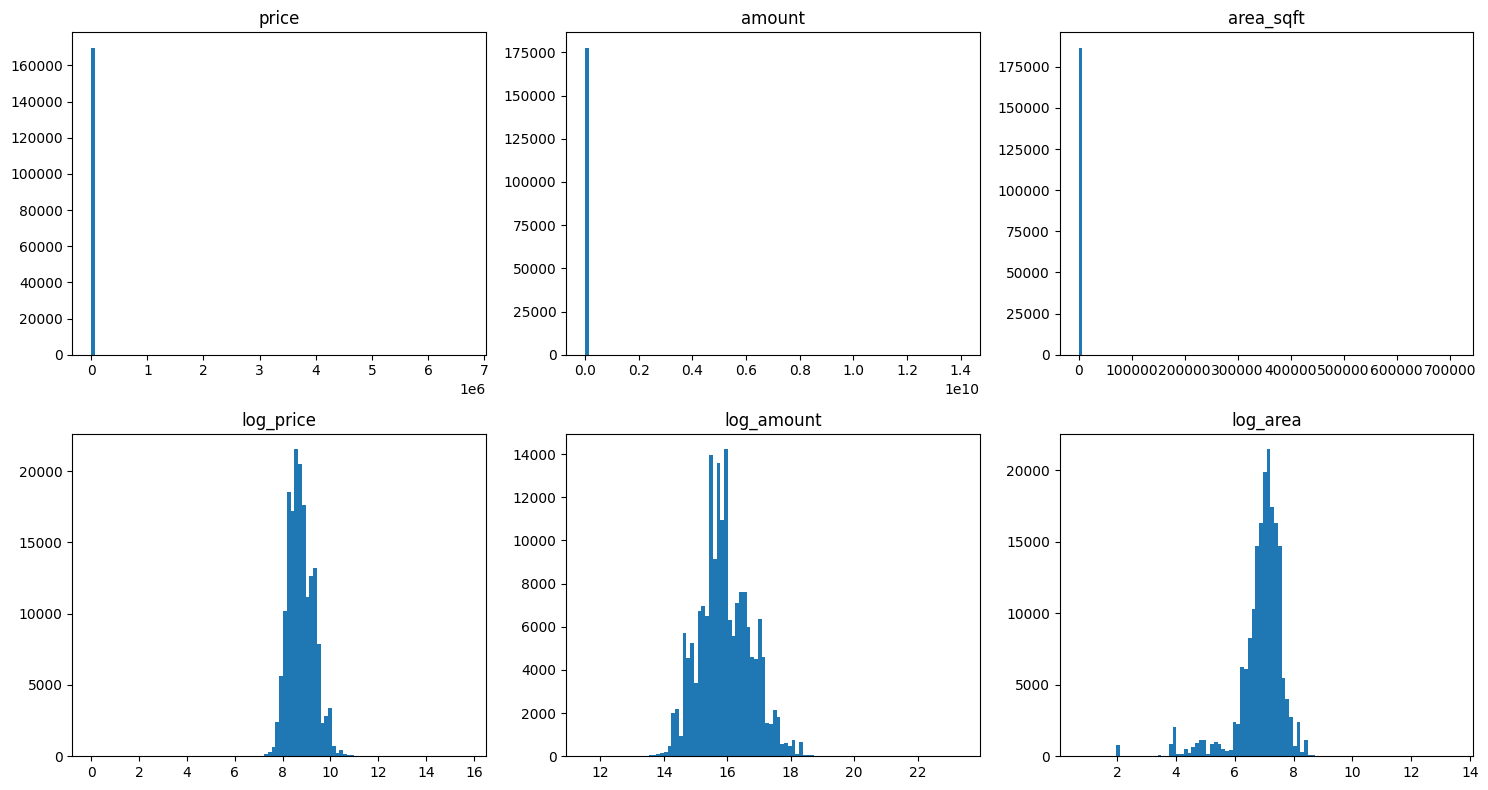

In [474]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

core_features = [
    "price",
    "amount",
    "area_sqft"
]

log_features = [
    "log_price",
    "log_amount",
    "log_area"
]

for i, feature in enumerate(core_features):
    axes[0, i].hist(
        df[feature].dropna(),
        bins=100
    )
    axes[0, i].set_title(feature)

for i, feature in enumerate(log_features):
    axes[1, i].hist(
        df[feature].dropna(),
        bins=100
    )
    axes[1, i].set_title(feature)

plt.tight_layout()
plt.show()

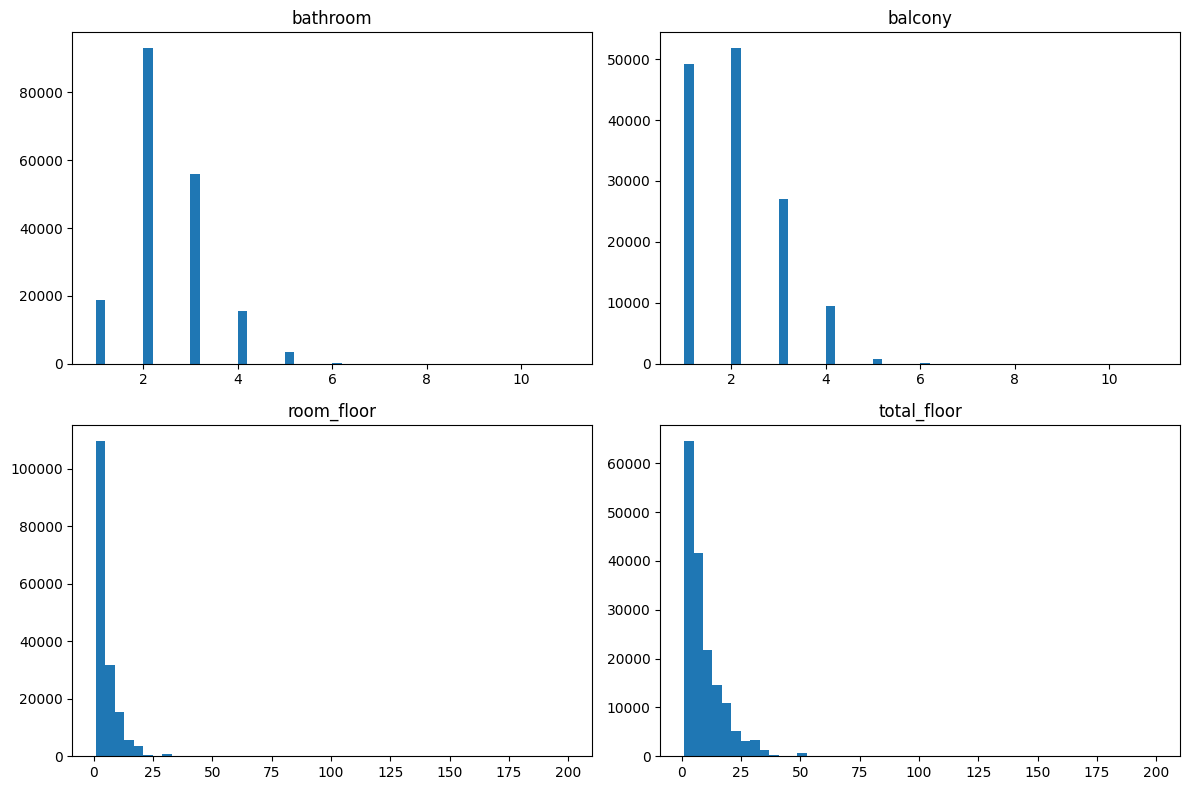

In [475]:
import matplotlib.pyplot as plt

numeric_features = [
    "bathroom",
    "balcony",
    "room_floor",
    "total_floor"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

for ax, feature in zip(
    axes.flatten(),
    numeric_features
):
    ax.hist(
        df[feature].dropna(),
        bins=50
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

**Observation**

- `price`, `amount`, and `area_sqft` exhibit strong right-skewness and long-tail distributions.
- Log transformation significantly improves the distributions of these variables.
- Correlations become substantially stronger after log transformation, indicating non-linear relationships in the raw feature space.
- `log_amount` is the strongest numeric predictor of `log_price`.
- `bathroom`, `balcony`, `room_floor`, and `total_floor` show moderate positive relationships with the target after log transformation.
- `log_area` contributes useful information but is weaker than expected for a property dataset.
- Extreme values exist in `amount`, `area_sqft`, and floor-related features.
- A small number of properties contain unusually high floor counts (up to 200 floors), while 99.9% of observations remain below 51 floors.

**Recommendation**

- Create and retain:
  - `log_price`
  - `log_amount`
  - `log_area`
- Use `log_price` as an alternative target during model evaluation.
- Retain both raw and log-transformed features for comparison.
- Flag extreme floor values for further investigation during preprocessing.
- Delay any outlier treatment until after the train/test split.
- Several numeric features exhibit substantial skewness and extreme outliers.
- Mean values are noticeably inflated relative to medians.
- Median statistics are therefore more robust and representative of the central tendency of the data.

#### 2.1.4. Categorical Feature Analysis

In [476]:
categorical_cols = [
    "location",
    "transaction",
    "furnishing",
    "facing",
    "overlooking",
    "car_parking",
    "ownership",
    "area_type"
]

In [477]:
categorical_summary = pd.DataFrame({
    "n_unique": df[categorical_cols].nunique(),
    "missing_pct": (
        df[categorical_cols]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

categorical_summary = (
    categorical_summary
    .sort_values(
        "n_unique",
        ascending=False
    )
)

categorical_summary

,n_unique,missing_pct
location,81,0.00
overlooking,19,43.43
facing,8,37.45
transaction,4,0.04
ownership,4,34.94
furnishing,3,1.54
car_parking,2,55.11
area_type,2,0.00


In [478]:
def category_target_analysis(
    df,
    categorical_cols,
    target="price"
):
    results = {}

    for col in categorical_cols:
        summary = (
            df.groupby(col)[target]
            .agg(
                count="count",
                median="median",
                mean="mean"
            )
            .sort_values(
                "median",
                ascending=False
            )
        )

        results[col] = summary

    return results


category_target_results = (
    category_target_analysis(
        df,
        categorical_cols,
        target="price"
    )
)


for col, result in category_target_results.items():
    print("\n" + "=" * 45)
    print(col.upper())
    print("=" * 45)

    print(result.head(20))


LOCATION
             count   median          mean
location                                 
mumbai        1692  20909.0  23575.618203
new-delhi    24849  10667.0  10944.105397
thane         1757   9820.0  10268.455322
navi-mumbai    669   8824.0   9876.959641
gurgaon      18238   8706.5  10323.493859
panchkula      319   7447.0   7304.072100
pune          2073   6928.0   7544.154848
kalyan         492   6852.0   7015.121951
bangalore    23168   6607.0   6765.679990
goa            971   6583.0   8430.051493
shimla          53   6296.0   6525.867925
noida         1239   6275.0   6885.889427
hyderabad    10041   6029.0   8168.086645
allahabad      163   6000.0   8724.024540
bhubaneswar    384   5872.5   5925.000000
bhiwandi        76   5841.0   7391.828947
kozhikode       53   5833.0   6098.735849
chennai       9252   5800.0   7594.165370
trivandrum     189   5738.0  12208.539683
patna          737   5714.0   6058.355495

TRANSACTION
               count   median          mean
transacti

In [479]:
# High Cardinality Analysis
def high_cardinality_analysis(
    df,
    categorical_cols,
    high_cardinality_threshold=50
):
    rows = []

    total_rows = len(df)

    for col in categorical_cols:

        non_null_count = (
            df[col]
            .notna()
            .sum()
        )

        n_unique = (
            df[col]
            .nunique(dropna=True)
        )

        unique_ratio = (
            n_unique / non_null_count
            if non_null_count > 0
            else np.nan
        )

        top_category = (
            df[col]
            .value_counts(
                dropna=True
            )
            .index[0]
            if non_null_count > 0
            else np.nan
        )

        top_category_share = (
            df[col]
            .value_counts(
                normalize=True,
                dropna=True
            )
            .iloc[0]
            * 100
            if non_null_count > 0
            else np.nan
        )

        cardinality_type = (
            "High"
            if n_unique > high_cardinality_threshold
            else "Low"
        )

        encoding_candidate = (
            "Frequency/Target"
            if n_unique > high_cardinality_threshold
            else "One-Hot"
        )

        rows.append({
            "feature": col,
            "non_null": non_null_count,
            "n_unique": n_unique,
            "unique_ratio": round(
                unique_ratio,
                4
            ),
            "top_category": top_category,
            "top_category_share_pct": round(
                top_category_share,
                2
            ),
            "cardinality": cardinality_type,
            "encoding_candidate": encoding_candidate
        })

    result = (
        pd.DataFrame(rows)
        .sort_values(
            by="n_unique",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return result


high_cardinality_df = (
    high_cardinality_analysis(
        df,
        categorical_cols
    )
)

high_cardinality_df

,feature,non_null,n_unique,unique_ratio,top_category,top_category_share_pct,cardinality,encoding_candidate
0,location,187531,81,0.0004,new-delhi,14.72,High,Frequency/Target
1,overlooking,106095,19,0.0002,Main Road,30.34,Low,One-Hot
2,facing,117298,8,0.0001,East,46.67,Low,One-Hot
3,transaction,187448,4,0.0000,Resale,76.91,Low,One-Hot
4,ownership,122014,4,0.0000,Freehold,91.98,Low,One-Hot
5,furnishing,184634,3,0.0000,Semi-Furnished,47.83,Low,One-Hot
6,car_parking,84174,2,0.0000,covered,86.31,Low,One-Hot
7,area_type,187531,2,0.0000,carpet,56.98,Low,One-Hot


**Observation**

- `location` and `society` are the only high-cardinality features.
- `location` exhibits substantial differences in median property prices across cities and is expected to be highly predictive.
- `society` contains over 10,000 categories and a high proportion of missing values.
- Several low-cardinality features show meaningful price differences:
  - `ownership`
  - `facing`
  - `overlooking`
  - `area_type`
  - `transaction`
- Missing values remain concentrated in:
  - `society`
  - `car_parking`
  - `overlooking`
  - `facing`
  - `ownership`

**Recommendation**

- Retain:
  - `location`
  - `society`
  - `ownership`
  - `facing`
  - `overlooking`
  - `transaction`
  - `furnishing`
  - `car_parking`
  - `area_type`
- Treat missing values as `Unknown` for informative-missing features.
- Use One-Hot Encoding for low-cardinality features.
- Use Frequency Encoding (or evaluate Target Encoding) for:
  - `location`
  - `society`

#### 2.1.5. Leakage Analysis

In [480]:
leakage_cols = [
    "price",
    "amount",
    "area_sqft",
    "log_price",
    "log_amount",
    "log_area"
]

df[leakage_cols].corr().round(3)

,price,amount,area_sqft,log_price,log_amount,log_area
price,1.000,0.763,0.011,0.232,0.156,0.006
amount,0.763,1.000,0.063,0.270,0.306,0.132
area_sqft,0.011,0.063,1.000,0.069,0.195,0.286
log_price,0.232,0.270,0.069,1.000,0.795,0.165
log_amount,0.156,0.306,0.195,0.795,1.000,0.537
log_area,0.006,0.132,0.286,0.165,0.537,1.000


In [481]:
def leakage_check(df):
    check_df = (
        df[
            [
                "price",
                "amount",
                "area_sqft"
            ]
        ]
        .dropna()
        .copy()
    )

    check_df["estimated_amount"] = (
        check_df["price"]
        * check_df["area_sqft"]
    )

    check_df["relative_error"] = (
        (
            check_df["amount"]
            - check_df["estimated_amount"]
        ).abs()
        /
        check_df["amount"]
    )

    print(
        "Median Relative Error:",
        round(
            check_df[
                "relative_error"
            ].median(),
            4
        )
    )

    print(
        "Rows Within 1% Error:",
        round(
            (
                check_df[
                    "relative_error"
                ]
                < 0.01
            ).mean()
            * 100,
            2
        ),
        "%"
    )

    print(
        "Rows Within 5% Error:",
        round(
            (
                check_df[
                    "relative_error"
                ]
                < 0.05
            ).mean()
            * 100,
            2
        ),
        "%"
    )


leakage_check(df)

Median Relative Error: 0.0461
Rows Within 1% Error: 47.91 %
Rows Within 5% Error: 50.21 %


**Observation**

- `amount` exhibits the strongest relationship with the target.
- No deterministic relationship was found between:
  - `price`
  - `amount`
  - `area_sqft`
- The derived feature `amount_per_sqft` shows only a weak correlation with `price`.
- Relative error analysis indicates that `amount` cannot be accurately reconstructed using `price × area_sqft`.
- Approximately 48% of observations fall within a 1% reconstruction error, but overall error variability remains high.

**Recommendation**

- Retain `amount` as a candidate predictive feature.
- No features are removed due to target leakage at this stage.
- Revisit the business definitions of `price` and `amount` before final model development.
- Proceed with train/test split and train-only preprocessing.

### 2.2. Data Splitting

In [482]:
RAW_DATA_DIR = Path("../data/raw")

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_df.to_csv(
    RAW_DATA_DIR / "train.csv",
    index=False
)

test_df.to_csv(
    RAW_DATA_DIR / "test.csv",
    index=False
)

train_df = pd.read_csv(
    RAW_DATA_DIR / "train.csv"
)

test_df = pd.read_csv(
    RAW_DATA_DIR / "test.csv"
)

print(train_df.shape)
print(test_df.shape)

(150024, 18)
(37507, 18)


### 3. Fit Preprocessing on Train Dataset

In [483]:
target = "price"

train_df = train_df.dropna(
    subset=[target]
)

test_df = test_df.dropna(
    subset=[target]
)

print(train_df.shape)
print(test_df.shape)

(135930, 18)
(33936, 18)


In [484]:
NUMERIC_COLS = [
    "amount",
    "area_sqft",
    "bathroom",
    "balcony",
    "room_floor",
    "total_floor"
]

CATEGORICAL_COLS = [
    "location",
    "transaction",
    "furnishing",
    "facing",
    "overlooking",
    "car_parking",
    "ownership",
    "area_type"
]

HIGH_CARDINALITY_COLS = [
    "location"
]

LOW_CARDINALITY_COLS = [
    "transaction",
    "furnishing",
    "facing",
    "overlooking",
    "car_parking",
    "ownership",
    "area_type"
]

In [485]:
numeric_fill_values = (
    train_df[NUMERIC_COLS]
    .median()
    .to_dict()
)

In [486]:
categorical_fill_values = {
    col: "Unknown"
    for col in CATEGORICAL_COLS
}

In [487]:
RARE_THRESHOLD = 20

rare_categories = {}

for col in HIGH_CARDINALITY_COLS:

    counts = (
        train_df[col]
        .value_counts()
    )

    rare_categories[col] = (
        counts[
            counts < RARE_THRESHOLD
        ]
        .index
        .tolist()
    )


In [488]:
frequency_maps = {}

for col in HIGH_CARDINALITY_COLS:

    frequency_maps[col] = (
        train_df[col]
        .value_counts(
            normalize=True
        )
        .to_dict()
    )

In [489]:
OUTLIER_COLS = [
    "amount",
    "area_sqft",
    "room_floor",
    "total_floor"
]

outlier_caps = {}

for col in OUTLIER_COLS:

    outlier_caps[col] = (
        train_df[col]
        .quantile(0.995)
    )

In [490]:
artifacts = {

    "numeric_fill_values":
        numeric_fill_values,

    "categorical_fill_values":
        categorical_fill_values,

    "rare_categories":
        rare_categories,

    "frequency_maps":
        frequency_maps,

    "outlier_caps":
        outlier_caps
}

In [491]:
def transform_dataset(
    df,
    artifacts
):

    df = df.copy()

    # ------------------------------
    # Numeric Imputation
    # ------------------------------

    for col, value in (
        artifacts[
            "numeric_fill_values"
        ].items()
    ):

        df[col] = (
            df[col]
            .fillna(value)
        )

    # ------------------------------
    # Categorical Imputation
    # ------------------------------

    for col, value in (
        artifacts[
            "categorical_fill_values"
        ].items()
    ):

        df[col] = (
            df[col]
            .fillna(value)
        )

    # ------------------------------
    # Rare Category Handling
    # ------------------------------

    for col in [
        "location"
    ]:

        rare_set = set(
            artifacts[
                "rare_categories"
            ][col]
        )

        df[col] = (
            df[col]
            .replace(
                list(rare_set),
                "Other"
            )
        )

    # ------------------------------
    # Frequency Encoding
    # ------------------------------

    for col in [
        "location"
    ]:

        df[f"{col}_freq"] = (
            df[col]
            .map(
                artifacts[
                    "frequency_maps"
                ][col]
            )
            .fillna(0)
        )

    # ------------------------------
    # Outlier Clipping
    # ------------------------------

    for col, cap in (
        artifacts[
            "outlier_caps"
        ].items()
    ):

        df[col] = (
            df[col]
            .clip(
                upper=cap
            )
        )

    return df


In [492]:
train_processed = (
    transform_dataset(
        train_df,
        artifacts
    )
)

test_processed = (
    transform_dataset(
        test_df,
        artifacts
    )
)

In [493]:
train_processed.info()

<class 'pandas.DataFrame'>
Index: 135930 entries, 0 to 150023
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   amount         135930 non-null  float64
 1   price          135930 non-null  float64
 2   location       135930 non-null  str    
 3   transaction    135930 non-null  str    
 4   furnishing     135930 non-null  str    
 5   facing         135930 non-null  str    
 6   overlooking    135930 non-null  str    
 7   bathroom       135930 non-null  float64
 8   balcony        135930 non-null  float64
 9   car_parking    135930 non-null  str    
 10  ownership      135930 non-null  str    
 11  area_type      135930 non-null  str    
 12  area_sqft      135930 non-null  float64
 13  room_floor     135930 non-null  float64
 14  total_floor    135930 non-null  float64
 15  log_price      135930 non-null  float64
 16  log_amount     135930 non-null  float64
 17  log_area       135930 non-null  float64
 18  